In [4]:
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tensorflow.keras.preprocessing import image
from sklearn.cluster import KMeans
import numpy as np
import os
import shutil

# Path to your mixed image folder
image_folder = r"C:\Users\User\Downloads\Skin-disease-dataset\output_skin_clean"

# Load MobileNetV2 model once
model = MobileNetV2(weights='imagenet', include_top=False, pooling='avg')

# Define feature extraction function
def extract_features(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    x = image.img_to_array(img)
    x = preprocess_input(x)
    x = np.expand_dims(x, axis=0)
    features = model.predict(x)
    return features[0]

# Process images
features = []
filenames = []

for fname in os.listdir(image_folder):
    if fname.lower().endswith((".jpg", ".png", ".jpeg")):
        path = os.path.join(image_folder, fname)
        feat = extract_features(path)
        features.append(feat)
        filenames.append(fname)

#features = np.array(features)
features = np.array(features, dtype=np.float64)  # <- FIXED LINE

# Cluster features
k = 5  # You can adjust this
kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(features)

# Organize images into cluster folders
for i in range(k):
    os.makedirs(f"grouped_images_v5/cluster_{i}", exist_ok=True)

for fname, cluster_id in zip(filenames, clusters):
    src = os.path.join(image_folder, fname)
    dst = os.path.join(f"grouped_images_v5/cluster_{cluster_id}", fname)
    shutil.copy(src, dst)

print("Image grouping complete.")


1/1 [==============================] - 0s 17ms/step
Image grouping complete.


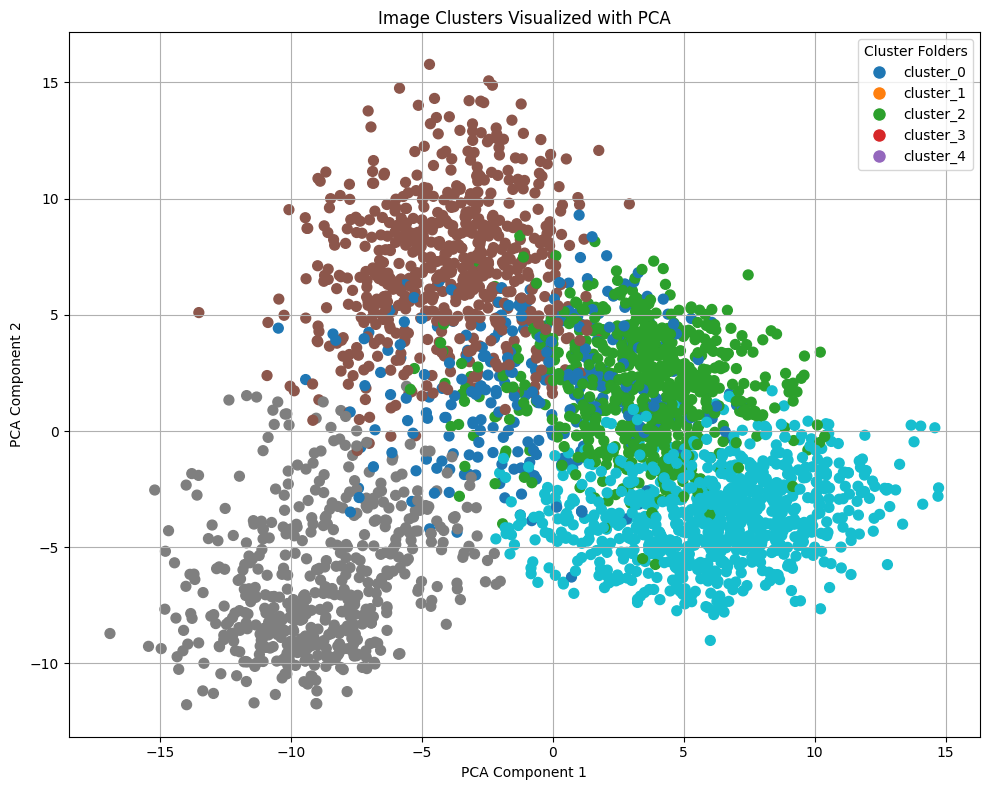

In [7]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

# features: NxD numpy array from your MobileNetV2 extractor
# clusters: cluster IDs assigned by KMeans, shape (N,)
# k: number of clusters

pca = PCA(n_components=2)
reduced_features = pca.fit_transform(features)

# Map cluster IDs to folder names
cluster_id_to_name = {i: f"cluster_{i}" for i in range(k)}

plt.figure(figsize=(10, 8))

# Scatter plot with points colored by cluster
scatter = plt.scatter(reduced_features[:, 0], reduced_features[:, 1], c=clusters, cmap='tab10', s=50)

# Create custom legend handles
unique_clusters = np.unique(clusters)
handles = []
for cluster_id in unique_clusters:
    color = plt.cm.tab10(cluster_id / 10)  # normalize for colormap
    handles.append(
        plt.Line2D([0], [0], marker='o', color='w', label=cluster_id_to_name[cluster_id],
                   markerfacecolor=color, markersize=10)
    )

plt.legend(handles=handles, title="Cluster Folders")

plt.title("Image Clusters Visualized with PCA")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import umap
import hdbscan
import matplotlib.pyplot as plt
import numpy as np
import os
import shutil

# === Your MobileNetV2 features & filenames should already be ready ===
# features = np.array([...])     # Shape: (N, 1280)
# filenames = ["img1.jpg", "img2.jpg", ...]
# image_folder = path to input images (already defined)

# === Step 1: Reduce with UMAP ===
umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
umap_embeddings = umap_model.fit_transform(features)

# === Step 2: Cluster with HDBSCAN ===
hdb = hdbscan.HDBSCAN(min_cluster_size=50 , min_samples=1)
cluster_labels = hdb.fit_predict(umap_embeddings)

# === Step 3: Save images into folders by cluster ID ===
output_dir = "grouped_images_umap_hdbscan_v4"
os.makedirs(output_dir, exist_ok=True)

for fname, cluster_id in zip(filenames, cluster_labels):
    # Assign folder name
    cluster_name = f"cluster_{cluster_id}" if cluster_id != -1 else "noise"
    cluster_path = os.path.join(output_dir, cluster_name)
    os.makedirs(cluster_path, exist_ok=True)

    # Copy image to cluster folder
    src = os.path.join(image_folder, fname)
    dst = os.path.join(cluster_path, fname)
    shutil.copy(src, dst)

print("✅ Images grouped into folders by UMAP + HDBSCAN clusters.")

# === Step 4 (Optional): Visualize Clusters ===
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    umap_embeddings[:, 0], umap_embeddings[:, 1],
    c=cluster_labels, cmap='tab10', s=50
)
plt.title("Skin Disease Clusters (UMAP + HDBSCAN)")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.colorbar(scatter, label="Cluster ID")
plt.grid(True)
plt.tight_layout()
plt.show()


Extracting features from images...
1/1 [==============================] - 0s 19ms/step
Extracted features for 2909 images.
Running KMeans clustering for visualization...


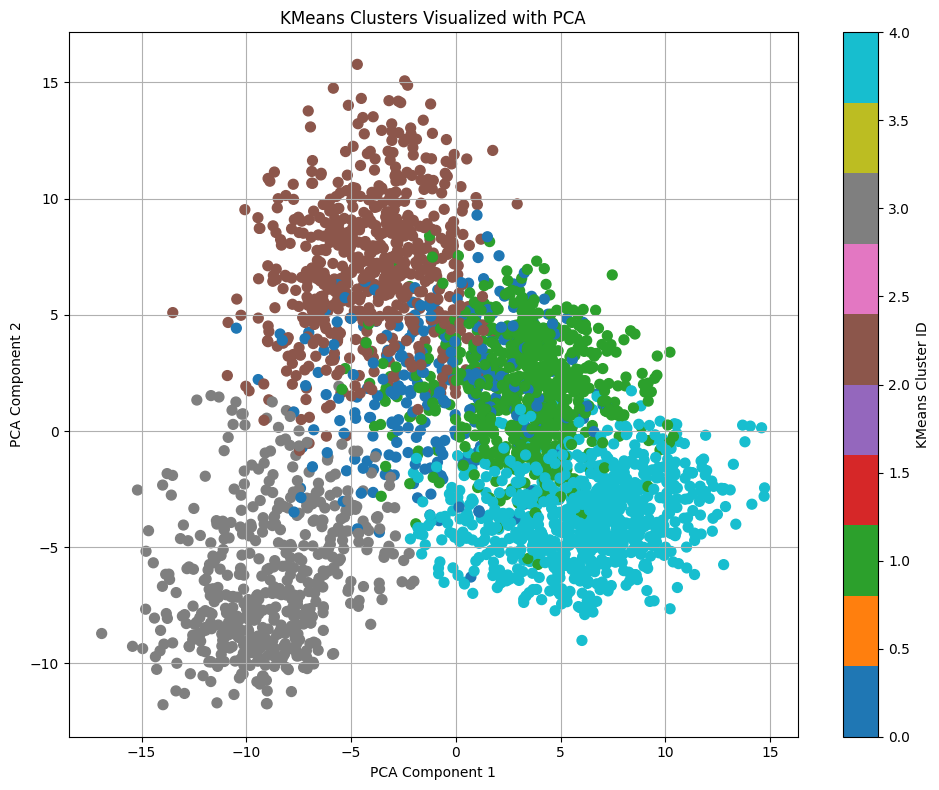

Running UMAP dimensionality reduction...


c:\Users\User\anaconda3\envs\shei_env\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Running HDBSCAN clustering...
Saving images into folders under 'grouped_images_umap_hdbscan_v6'...


C:\Users\User\AppData\Roaming\Python\Python310\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\User\AppData\Roaming\Python\Python310\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


✅ Images grouped into folders by UMAP + HDBSCAN clusters.


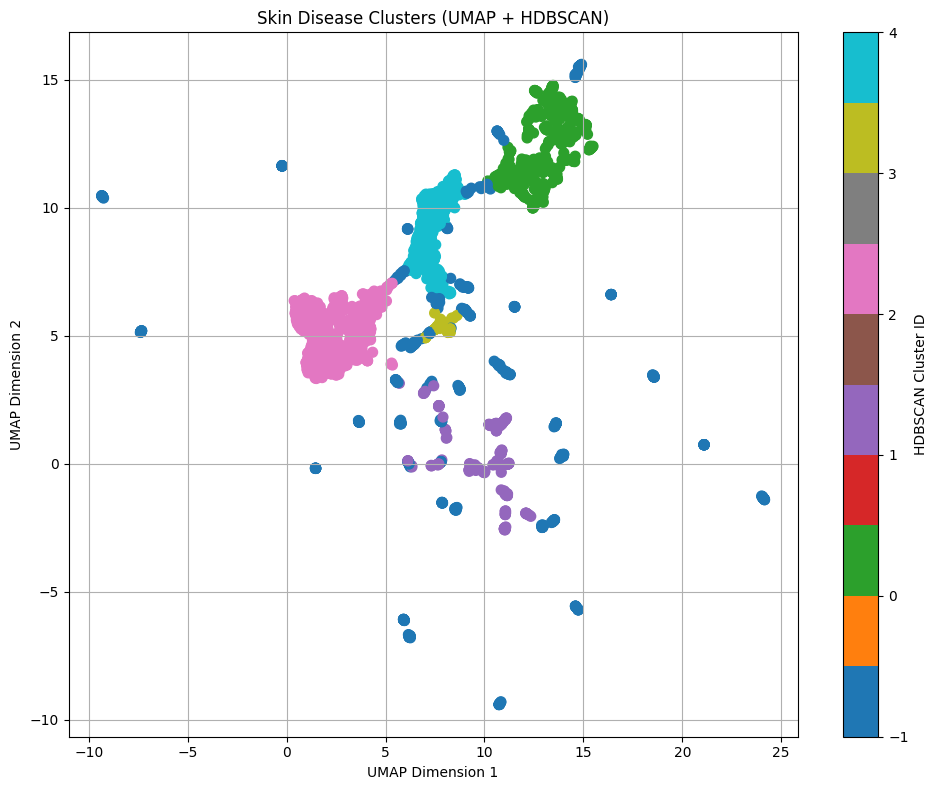

In [ ]:
# Both kn and HDBSCAN clustering with UMAP visualization
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import umap
import hdbscan
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tensorflow.keras.preprocessing import image

# === Config ===
image_folder = r"C:\Users\User\Downloads\Skin-disease-dataset\output_skin_clean"
output_dir = "grouped_images_umap_hdbscan_v6"
k = 5  # number of KMeans clusters for visualization only

# === Step 0: Feature extraction ===
print("Extracting features from images...")
model = MobileNetV2(weights='imagenet', include_top=False, pooling='avg')

def extract_features(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    x = image.img_to_array(img)
    x = preprocess_input(x)
    x = np.expand_dims(x, axis=0)
    features = model.predict(x)
    return features[0]

features = []
filenames = []

for fname in os.listdir(image_folder):
    if fname.lower().endswith((".jpg", ".png", ".jpeg")):
        path = os.path.join(image_folder, fname)
        feat = extract_features(path)
        features.append(feat)
        filenames.append(fname)

features = np.array(features, dtype=np.float64)
print(f"Extracted features for {len(filenames)} images.")

# === Step 1: KMeans clustering + PCA visualization ===
print("Running KMeans clustering for visualization...")
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans_labels = kmeans.fit_predict(features)

pca = PCA(n_components=2)
pca_features = pca.fit_transform(features)

# Plot KMeans clusters
plt.figure(figsize=(10, 8))
scatter = plt.scatter(pca_features[:, 0], pca_features[:, 1], c=kmeans_labels, cmap='tab10', s=50)
plt.title("KMeans Clusters Visualized with PCA")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(scatter, label="KMeans Cluster ID")
plt.grid(True)
plt.tight_layout()
plt.show()

# === Step 2: UMAP dimensionality reduction ===
print("Running UMAP dimensionality reduction...")
umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
umap_embeddings = umap_model.fit_transform(features)

# === Step 3: HDBSCAN clustering ===
print("Running HDBSCAN clustering...")
hdb = hdbscan.HDBSCAN(min_cluster_size=50)
hdb_labels = hdb.fit_predict(umap_embeddings)

# === Step 4: Save images grouped by HDBSCAN clusters ===
print(f"Saving images into folders under '{output_dir}'...")
os.makedirs(output_dir, exist_ok=True)

for fname, cluster_id in zip(filenames, hdb_labels):
    cluster_name = f"cluster_{cluster_id}" if cluster_id != -1 else "noise"
    cluster_path = os.path.join(output_dir, cluster_name)
    os.makedirs(cluster_path, exist_ok=True)

    src = os.path.join(image_folder, fname)
    dst = os.path.join(cluster_path, fname)
    shutil.copy(src, dst)

print("✅ Images grouped into folders by UMAP + HDBSCAN clusters.")

# === Step 5: Visualize UMAP + HDBSCAN clusters ===
plt.figure(figsize=(10, 8))
scatter = plt.scatter(umap_embeddings[:, 0], umap_embeddings[:, 1], c=hdb_labels, cmap='tab10', s=50)
plt.title("Skin Disease Clusters (UMAP + HDBSCAN)")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.colorbar(scatter, label="HDBSCAN Cluster ID")
plt.grid(True)
plt.tight_layout()
plt.show()


c:\Users\User\anaconda3\envs\shei_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Extracting features from images...
1/1 [==============================] - 0s 19ms/step
✅ Extracted features for 3779 images.
Running KMeans clustering for PCA visualization...


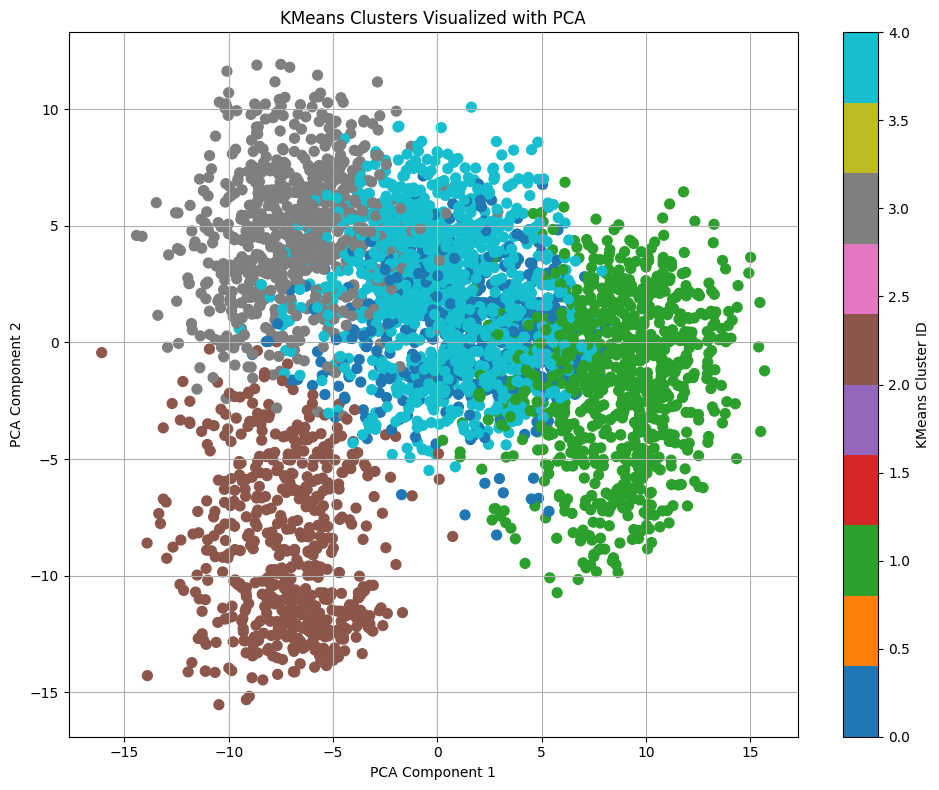

Running UMAP...


c:\Users\User\anaconda3\envs\shei_env\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Running HDBSCAN clustering...
Reassigning noise points to nearest clusters...
✅ Noise reassignment complete.
Saving grouped images under 'grouped_images_umap_hdbscan_reassigned_v2'...


C:\Users\User\AppData\Roaming\Python\Python310\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\User\AppData\Roaming\Python\Python310\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


✅ Images grouped into folders by UMAP + HDBSCAN with reassigned noise.


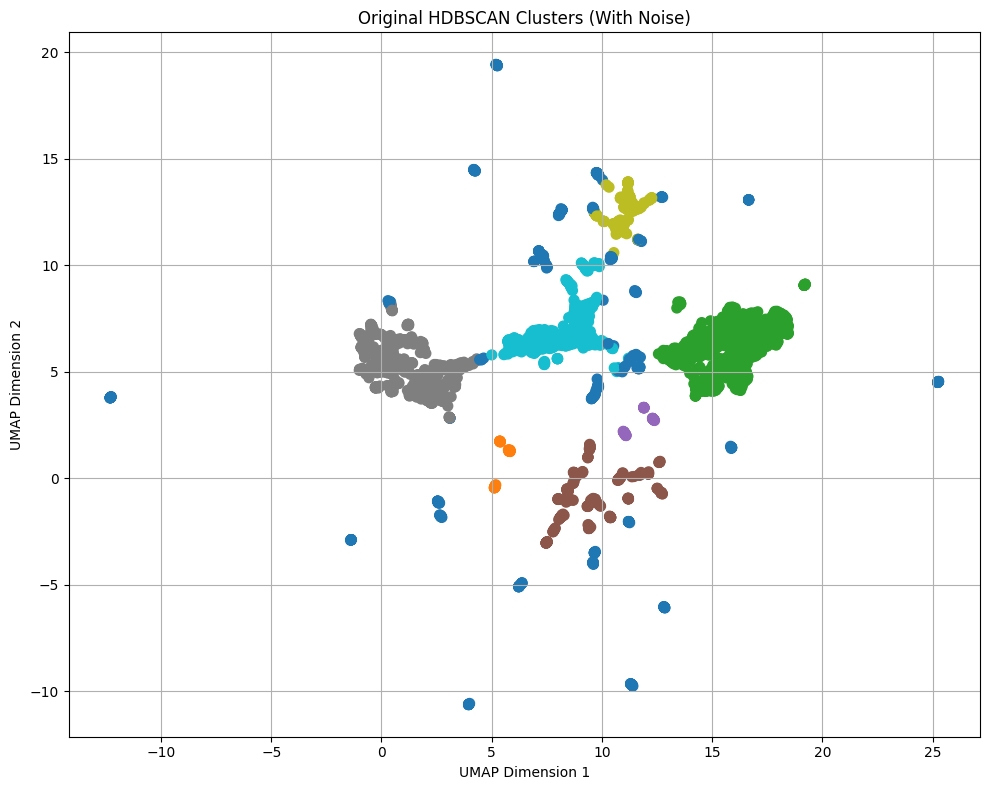

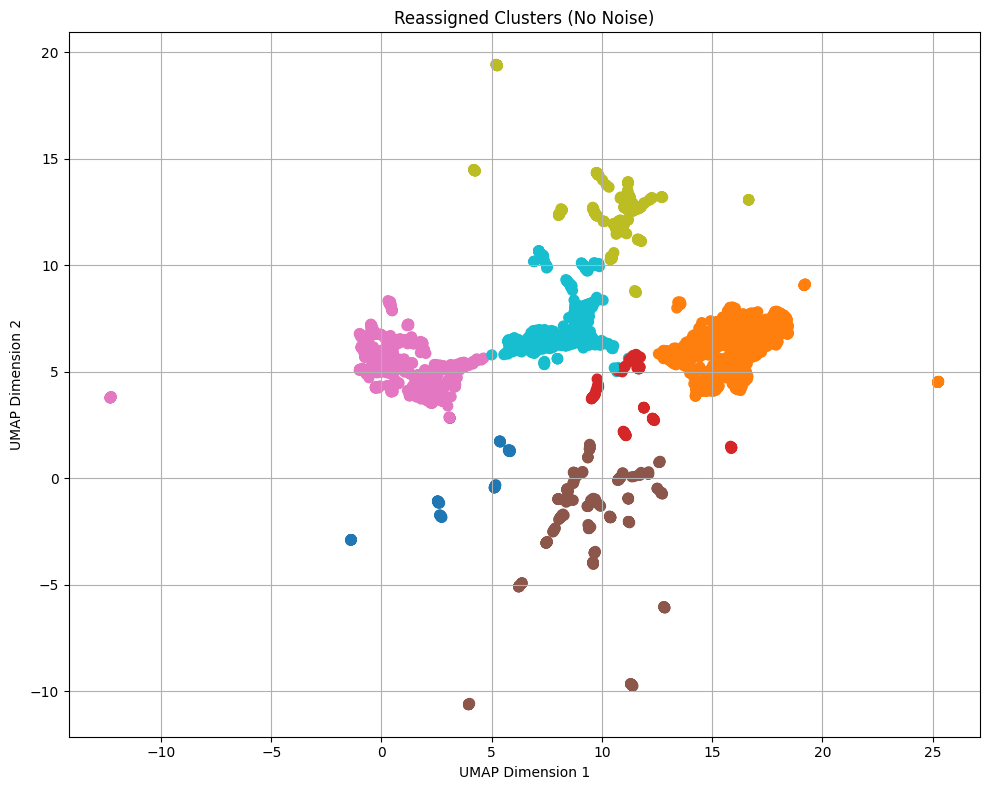

In [ ]:
# Noirse reduction , assigning noise to closest cluster using mobilenet_v2 features
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import umap
import hdbscan
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tensorflow.keras.preprocessing import image

# === Config ===
image_folder = r"C:\Users\User\Downloads\Skin-disease-dataset\v6_merged"
output_dir = "grouped_images_umap_hdbscan_reassigned_v2"
k = 5  # for KMeans visualization only

# === Step 0: Feature extraction ===
print("Extracting features from images...")
model = MobileNetV2(weights='imagenet', include_top=False, pooling='avg')

def extract_features(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    x = image.img_to_array(img)
    x = preprocess_input(x)
    x = np.expand_dims(x, axis=0)
    features = model.predict(x)
    return features[0]

features = []
filenames = []

for fname in os.listdir(image_folder):
    if fname.lower().endswith((".jpg", ".png", ".jpeg")):
        path = os.path.join(image_folder, fname)
        feat = extract_features(path)
        features.append(feat)
        filenames.append(fname)

features = np.array(features, dtype=np.float64)
print(f"✅ Extracted features for {len(filenames)} images.")

# === Step 1: KMeans clustering + PCA for visualization ===
print("Running KMeans clustering for PCA visualization...")
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans_labels = kmeans.fit_predict(features)

pca = PCA(n_components=2)
pca_features = pca.fit_transform(features)

# Plot PCA with KMeans
plt.figure(figsize=(10, 8))
scatter = plt.scatter(pca_features[:, 0], pca_features[:, 1], c=kmeans_labels, cmap='tab10', s=50)
plt.title("KMeans Clusters Visualized with PCA")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(scatter, label="KMeans Cluster ID")
plt.grid(True)
plt.tight_layout()
plt.show()

# === Step 2: UMAP dimensionality reduction ===
print("Running UMAP...")
umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
umap_embeddings = umap_model.fit_transform(features)

# === Step 3: HDBSCAN clustering ===
print("Running HDBSCAN clustering...")
hdb = hdbscan.HDBSCAN(min_cluster_size=50)
hdb_labels = hdb.fit_predict(umap_embeddings)

# === Step 4: Reassign noise points (-1) to nearest cluster centroid ===
print("Reassigning noise points to nearest clusters...")

# Compute cluster centroids
cluster_points = defaultdict(list)
for emb, label in zip(umap_embeddings, hdb_labels):
    if label != -1:
        cluster_points[label].append(emb)

cluster_centroids = {label: np.mean(pts, axis=0) for label, pts in cluster_points.items()}

# Reassign labels
reassigned_labels = hdb_labels.copy()
for i, label in enumerate(hdb_labels):
    if label == -1:
        point = umap_embeddings[i]
        distances = {cid: np.linalg.norm(point - centroid)
                     for cid, centroid in cluster_centroids.items()}
        nearest_cluster = min(distances, key=distances.get)
        reassigned_labels[i] = nearest_cluster

print("✅ Noise reassignment complete.")

# === Step 5: Save grouped images ===
print(f"Saving grouped images under '{output_dir}'...")
os.makedirs(output_dir, exist_ok=True)

for fname, cluster_id in zip(filenames, reassigned_labels):
    cluster_path = os.path.join(output_dir, f"cluster_{cluster_id}")
    os.makedirs(cluster_path, exist_ok=True)
    src = os.path.join(image_folder, fname)
    dst = os.path.join(cluster_path, fname)
    shutil.copy(src, dst)

print("✅ Images grouped into folders by UMAP + HDBSCAN with reassigned noise.")

# === Step 6: Visualize UMAP + original vs reassigned clusters ===
plt.figure(figsize=(10, 8))
plt.scatter(umap_embeddings[:, 0], umap_embeddings[:, 1], c=hdb_labels, cmap='tab10', s=50)
plt.title("Original HDBSCAN Clusters (With Noise)")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
plt.scatter(umap_embeddings[:, 0], umap_embeddings[:, 1], c=reassigned_labels, cmap='tab10', s=50)
plt.title("Reassigned Clusters (No Noise)")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.grid(True)
plt.tight_layout()
plt.show()



Loading custom .h5 model...
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenetv2_1.00_224 (Funct  (None, 7, 7, 1280)       2257984   
 ional)                                                          
                                                                 
 global_average_pooling2d (G  (None, 1280)             0         
 lobalAveragePooling2D)                                          
                                                                 
 batch_normalization (BatchN  (None, 1280)             5120      
 ormalization)                                                   
                                                                 
 dense (Dense)               (None, 512)               655872    
                                                                 
 dropout (Dropout)           (None, 512)               0         
                            

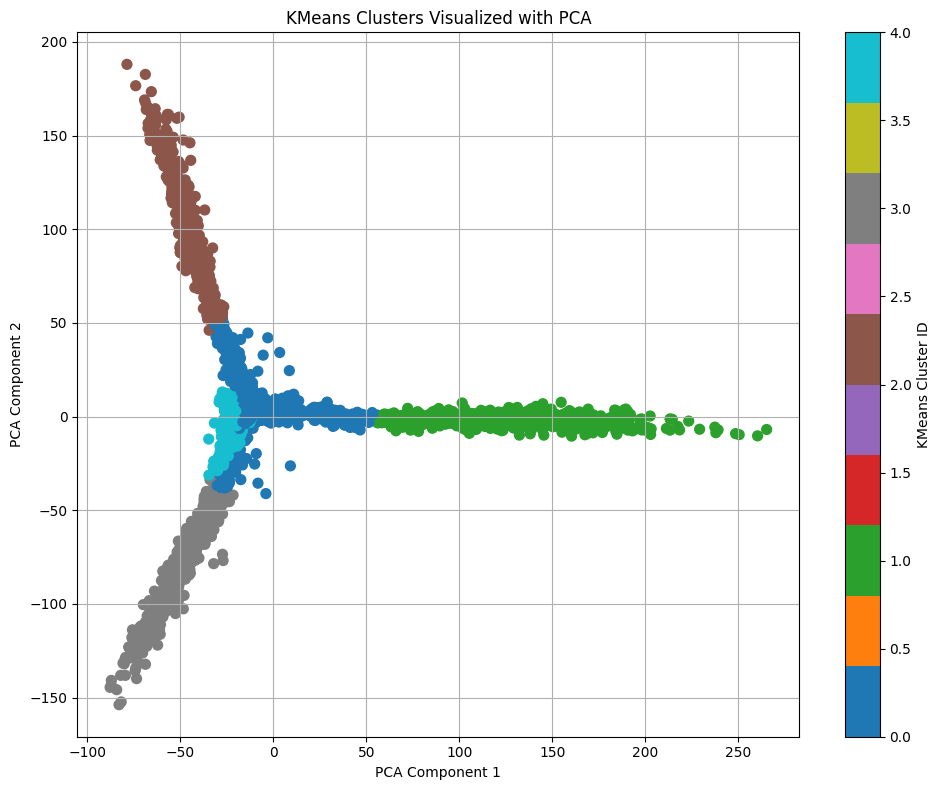

Running UMAP...


c:\Users\User\anaconda3\envs\shei_env\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Running HDBSCAN clustering...
Reassigning noise points to nearest clusters...
✅ Noise reassignment complete.
Saving grouped images under 'grouped_images_umap_hdbscan_reassigned_v6'...


C:\Users\User\AppData\Roaming\Python\Python310\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\User\AppData\Roaming\Python\Python310\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


✅ Images grouped into folders by UMAP + HDBSCAN with reassigned noise.


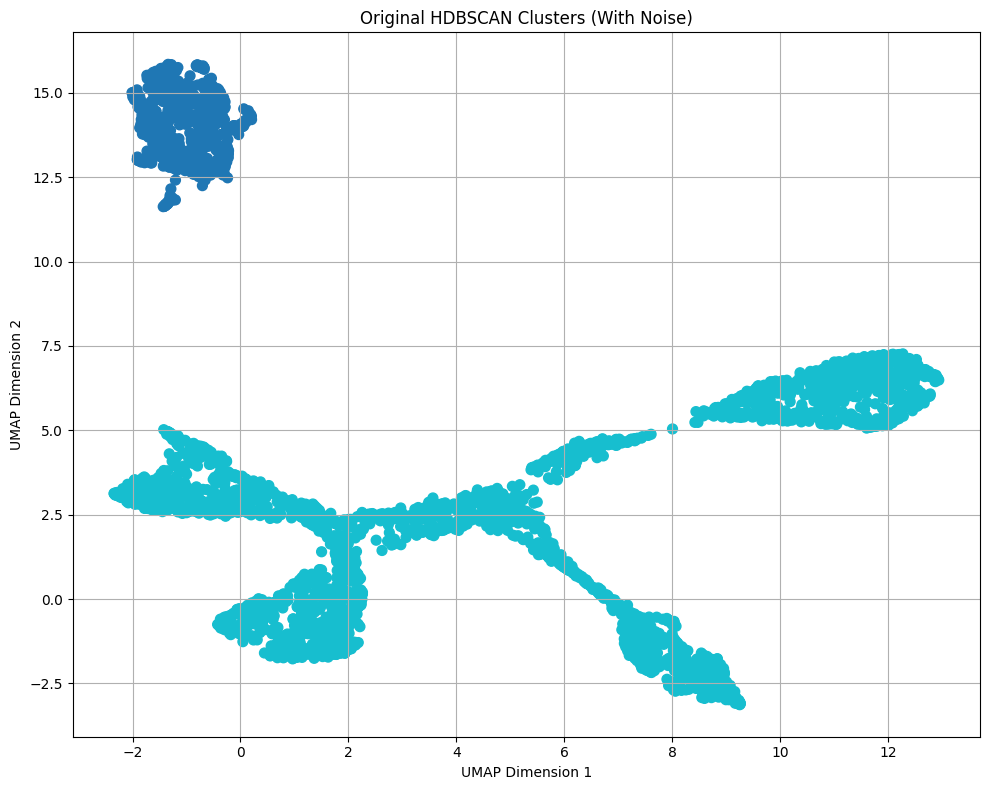

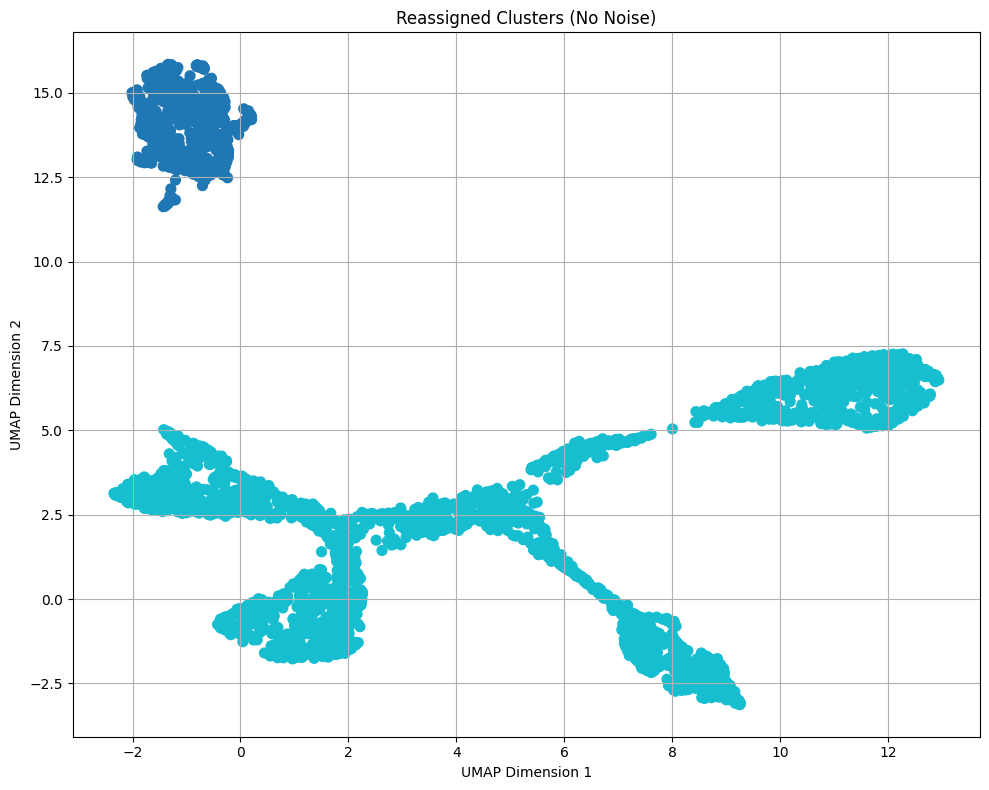

In [7]:
#usding my trained model

# === Imports ===
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import umap
import hdbscan
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.preprocessing import image

# === Config ===
image_folder = r"C:\Users\User\Downloads\Skin-disease-dataset\v6_merged"
output_dir = "grouped_images_umap_hdbscan_reassigned_v6"
h5_model_path = "299-model-test-v5.h5"  
img_size = (224, 224)  
k = 5  # for KMeans visualization

# === Step 0: Load your .h5 model ===
print("Loading custom .h5 model...")
full_model = load_model(h5_model_path)
full_model.summary()  # Optional: See model architecture to pick feature layer

# === Extract features from the layer before final dense/classification ===
# 🔁 Replace 'your_feature_layer_name' or use index (e.g., -2) if you're unsure
# Example: feature_layer = full_model.get_layer('global_average_pooling2d') or index -2
feature_extractor = Model(inputs=full_model.input, outputs=full_model.layers[-2].output)

# === Step 1: Feature extraction ===
print("Extracting features from images...")

def extract_features(img_path):
    img = image.load_img(img_path, target_size=img_size)
    x = image.img_to_array(img)
    x = x / 255.0  # ⬅️ Apply same preprocessing used in training
    x = np.expand_dims(x, axis=0)
    features = feature_extractor.predict(x, verbose=0)
    return features[0]

features = []
filenames = []

for fname in os.listdir(image_folder):
    if fname.lower().endswith((".jpg", ".png", ".jpeg")):
        path = os.path.join(image_folder, fname)
        feat = extract_features(path)
        features.append(feat)
        filenames.append(fname)

features = np.array(features, dtype=np.float64)
print(f"✅ Extracted features for {len(filenames)} images.")

# === Step 2: KMeans + PCA visualization (optional) ===
print("Running KMeans clustering for PCA visualization...")
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans_labels = kmeans.fit_predict(features)

pca = PCA(n_components=2)
pca_features = pca.fit_transform(features)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(pca_features[:, 0], pca_features[:, 1], c=kmeans_labels, cmap='tab10', s=50)
plt.title("KMeans Clusters Visualized with PCA")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(scatter, label="KMeans Cluster ID")
plt.grid(True)
plt.tight_layout()
plt.show()

# === Step 3: UMAP reduction ===
print("Running UMAP...")
umap_model = umap.UMAP(n_neighbors=50, min_dist=0.1, n_components=2, random_state=42)
umap_embeddings = umap_model.fit_transform(features)

# === Step 4: HDBSCAN Clustering ===
print("Running HDBSCAN clustering...")
hdb = hdbscan.HDBSCAN(min_cluster_size=50)
hdb_labels = hdb.fit_predict(umap_embeddings)

# === Step 5: Reassign noise points ===
print("Reassigning noise points to nearest clusters...")

cluster_points = defaultdict(list)
for emb, label in zip(umap_embeddings, hdb_labels):
    if label != -1:
        cluster_points[label].append(emb)

cluster_centroids = {label: np.mean(pts, axis=0) for label, pts in cluster_points.items()}

reassigned_labels = hdb_labels.copy()
for i, label in enumerate(hdb_labels):
    if label == -1:
        point = umap_embeddings[i]
        distances = {cid: np.linalg.norm(point - centroid) for cid, centroid in cluster_centroids.items()}
        nearest_cluster = min(distances, key=distances.get)
        reassigned_labels[i] = nearest_cluster

print("✅ Noise reassignment complete.")

# === Step 6: Save grouped images ===
print(f"Saving grouped images under '{output_dir}'...")
os.makedirs(output_dir, exist_ok=True)

for fname, cluster_id in zip(filenames, reassigned_labels):
    cluster_path = os.path.join(output_dir, f"cluster_{cluster_id}")
    os.makedirs(cluster_path, exist_ok=True)
    src = os.path.join(image_folder, fname)
    dst = os.path.join(cluster_path, fname)
    shutil.copy(src, dst)

print("✅ Images grouped into folders by UMAP + HDBSCAN with reassigned noise.")

# === Step 7: Visualize Clusters ===
plt.figure(figsize=(10, 8))
plt.scatter(umap_embeddings[:, 0], umap_embeddings[:, 1], c=hdb_labels, cmap='tab10', s=50)
plt.title("Original HDBSCAN Clusters (With Noise)")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
plt.scatter(umap_embeddings[:, 0], umap_embeddings[:, 1], c=reassigned_labels, cmap='tab10', s=50)
plt.title("Reassigned Clusters (No Noise)")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.grid(True)
plt.tight_layout()
plt.show()


In [2]:
cluster_labels_map = {
    0: "Athelete Foot",
    1: "Acne or Psoriasis",
    2: "Athelete Foot",
    3: "Athlete Foot",
    4: "Nail Fungus",
    5: "Ringworm",
    6: "Distorted Images"
}


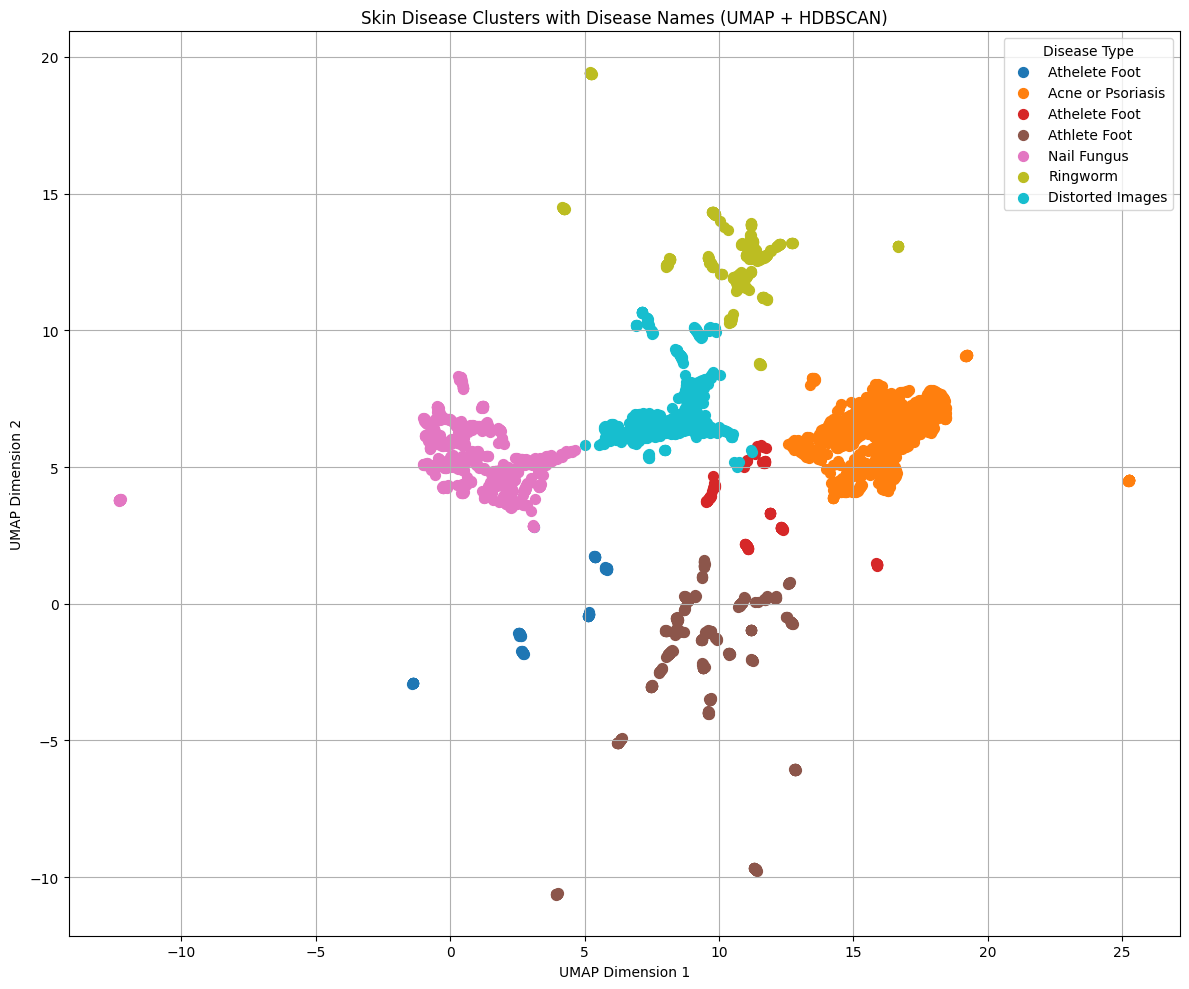

In [3]:
# === Visualize UMAP with Disease Labels ===
import matplotlib.patches as mpatches

plt.figure(figsize=(12, 10))

unique_clusters = sorted(set(reassigned_labels))
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_clusters)))

for cid, color in zip(unique_clusters, colors):
    idx = np.where(reassigned_labels == cid)
    label = cluster_labels_map.get(cid, f"Cluster {cid}")
    plt.scatter(umap_embeddings[idx, 0], umap_embeddings[idx, 1], label=label, s=50, color=color)

plt.title("Skin Disease Clusters with Disease Names (UMAP + HDBSCAN)")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.legend(title="Disease Type")
plt.grid(True)
plt.tight_layout()
plt.show()


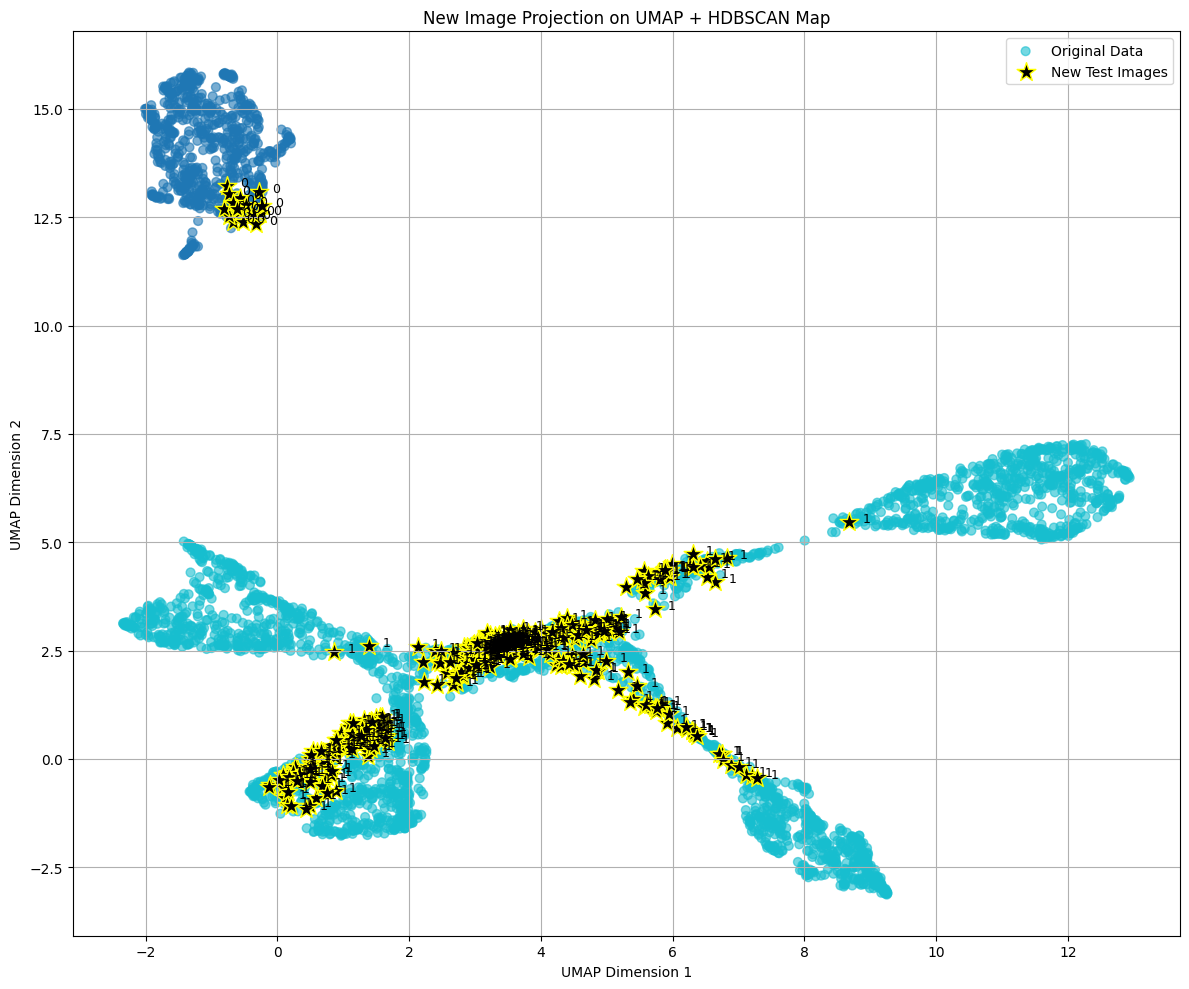

[✓] 30_BA-impetigo (4)_foreground.jpg → Assigned to Cluster 1
[✓] 31_BA-impetigo (26)_foreground.jpg → Assigned to Cluster 1
[✓] 32_BA-impetigo (85)_foreground.jpg → Assigned to Cluster 1
[✓] 33_BA-impetigo (53)_foreground.jpg → Assigned to Cluster 1
[✓] 34_BA-impetigo (40)_foreground.jpg → Assigned to Cluster 1
[✓] 35_BA-impetigo (10)_foreground.jpg → Assigned to Cluster 1
[✓] 36_BA-impetigo (30)_foreground.jpg → Assigned to Cluster 1
[✓] 37_BA-impetigo (7)_foreground.jpg → Assigned to Cluster 1
[✓] 38_BA-impetigo (60)_foreground.jpg → Assigned to Cluster 1
[✓] 41_BA-impetigo (89)_foreground.jpg → Assigned to Cluster 1
[✓] 42_BA-impetigo (2)_foreground.jpg → Assigned to Cluster 1
[✓] 43_BA-impetigo (78)_foreground.jpg → Assigned to Cluster 1
[✓] 44_BA-impetigo (11)_foreground.jpg → Assigned to Cluster 1
[✓] 45_BA-impetigo (37)_foreground.jpg → Assigned to Cluster 1
[✓] 46_BA-impetigo (53)_foreground.jpg → Assigned to Cluster 1
[✓] 47_BA-impetigo (25)_foreground.jpg → Assigned to Clust

In [9]:
# === Step 7: Project and visualize new images ===
new_images_folder = r"C:\Users\User\Downloads\Skin-disease-dataset\new_disease_clean_v8"

new_filenames = []
new_features = []

for fname in os.listdir(new_images_folder):
    if fname.lower().endswith((".jpg", ".png", ".jpeg")):
        img_path = os.path.join(new_images_folder, fname)
        feat = extract_features(img_path)
        new_features.append(feat)
        new_filenames.append(fname)

new_features = np.array(new_features)

# === Project new features into UMAP space ===
new_umap_embeddings = umap_model.transform(new_features)

# === Assign new images to nearest cluster ===
new_assignments = []

for emb in new_umap_embeddings:
    distances = {cid: np.linalg.norm(emb - centroid) for cid, centroid in cluster_centroids.items()}
    nearest_cluster = min(distances, key=distances.get)
    new_assignments.append(nearest_cluster)

# === Visualize original + new data together ===
plt.figure(figsize=(12, 10))

# Original clustered data
plt.scatter(
    umap_embeddings[:, 0], umap_embeddings[:, 1],
    c=reassigned_labels, cmap='tab10', s=40, alpha=0.6, label="Original Data"
)

# New projected points
plt.scatter(
    new_umap_embeddings[:, 0], new_umap_embeddings[:, 1],
    c='black', marker='*', edgecolors='yellow', s=200, label="New Test Images"
)

for (x, y), name, cluster in zip(new_umap_embeddings, new_filenames, new_assignments):
    plt.text(x + 0.2, y, f"{cluster}", fontsize=9)

plt.title("New Image Projection on UMAP + HDBSCAN Map")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# === Optional: Print assignments ===
for fname, cluster in zip(new_filenames, new_assignments):
    print(f"[✓] {fname} → Assigned to Cluster {cluster}")


In [11]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from sklearn.ensemble import IsolationForest

# === CONFIG ===
new_images_folder = r"C:\Users\User\Downloads\Skin-disease-dataset\new_disease_clean_v8"
model = ...  # your loaded .h5 or MobileNetV2 model
umap_model = ...  # already fitted UMAP model (from training)
train_umap_embeddings = ...  # embeddings from your training images

# === Step 1: Load and Extract Features ===
def extract_features(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)
    features = model.predict(x)
    return features[0]

new_filenames, new_features = [], []

for fname in os.listdir(new_images_folder):
    if fname.lower().endswith((".jpg", ".png", ".jpeg")):
        img_path = os.path.join(new_images_folder, fname)
        feat = extract_features(img_path)
        new_features.append(feat)
        new_filenames.append(fname)

new_features = np.array(new_features)

# === Step 2: Project to UMAP Space ===
new_umap_embeddings = umap_model.transform(new_features)

# === Step 3: Train Isolation Forest on Train UMAP Embeddings ===
iso = IsolationForest(contamination=0.02, random_state=42)
iso.fit(train_umap_embeddings)

# === Step 4: Predict Anomalies ===
preds = iso.predict(new_umap_embeddings)  # -1 = outlier, 1 = inlier
scores = iso.decision_function(new_umap_embeddings)  # anomaly scores

# === Step 5: Visualize New Points ===
plt.figure(figsize=(12, 10))

# Show training embeddings in background
plt.scatter(train_umap_embeddings[:, 0], train_umap_embeddings[:, 1], c='lightgray', s=20, label='Training Data')

# Plot normal vs anomalies
for i, (x, y) in enumerate(new_umap_embeddings):
    if preds[i] == -1:
        plt.scatter(x, y, color='red', marker='x', s=100)
        plt.text(x + 0.2, y, f"Anomaly", fontsize=8, color='red')
    else:
        plt.scatter(x, y, color='green', marker='o', edgecolor='black', s=80)

plt.title("New Images Projected onto UMAP (Anomaly Detection with Isolation Forest)")
plt.xlabel("UMAP Dim 1")
plt.ylabel("UMAP Dim 2")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# === Step 6: Print Results ===
for fname, pred, score in zip(new_filenames, preds, scores):
    status = "🚨 Anomaly" if pred == -1 else "✓ Normal"
    print(f"{status} → {fname} (Score: {score:.4f})")


AttributeError: 'ellipsis' object has no attribute 'predict'

In [10]:
# === Combine original + new features and embeddings ===
combined_features = np.vstack([features, new_features])
combined_filenames = filenames + new_filenames
combined_labels = [f"original_{i}" for i in range(len(filenames))] + [f"new_{i}" for i in range(len(new_filenames))]

# Re-run UMAP
combined_umap_embeddings = umap_model.fit_transform(combined_features)

# Re-run HDBSCAN
print("Running HDBSCAN on combined data...")
hdb_combined = hdbscan.HDBSCAN(min_cluster_size=50)
combined_hdb_labels = hdb_combined.fit_predict(combined_umap_embeddings)


Running HDBSCAN on combined data...


C:\Users\User\AppData\Roaming\Python\Python310\site-packages\sklearn\utils\deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

C:\Users\User\AppData\Roaming\Python\Python310\site-packages\sklearn\utils\deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



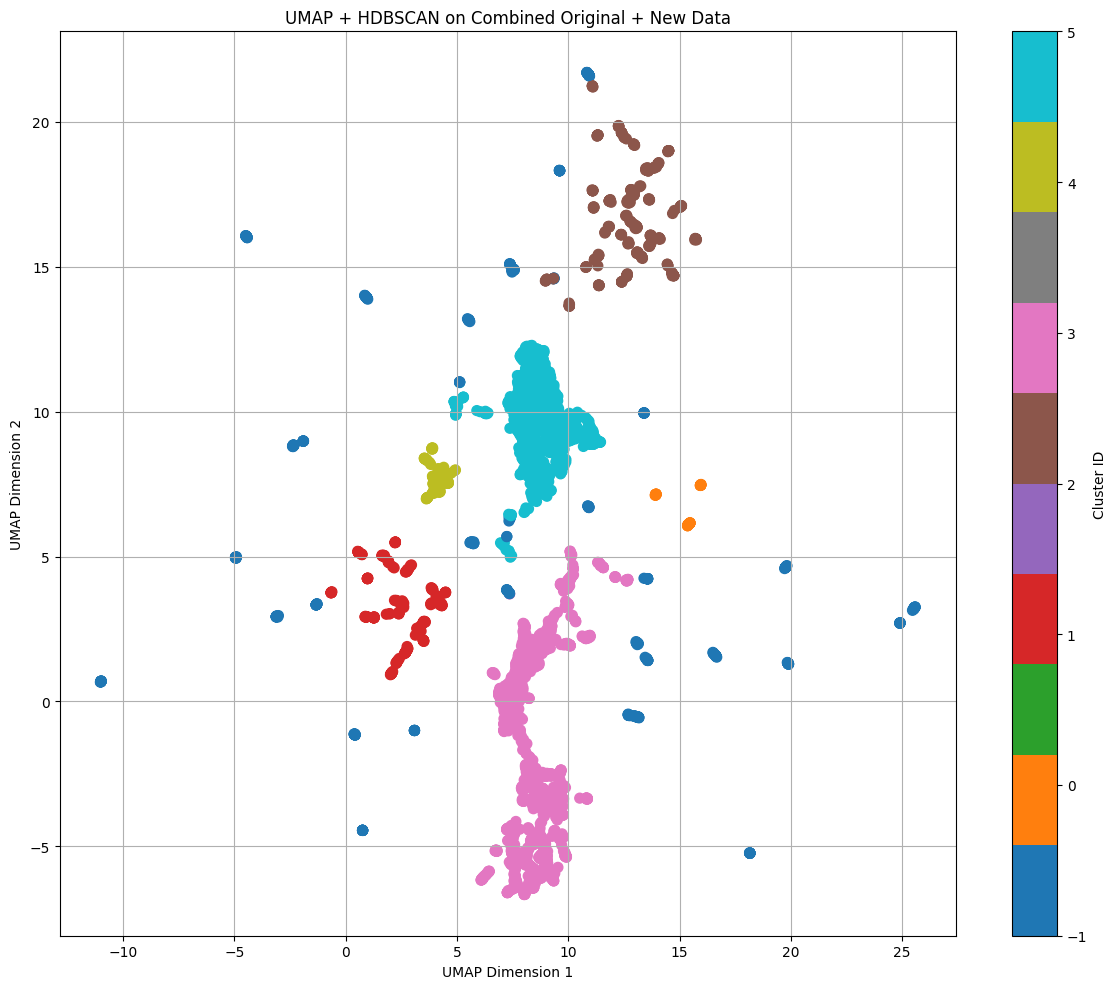

In [11]:
plt.figure(figsize=(12, 10))
scatter = plt.scatter(
    combined_umap_embeddings[:, 0],
    combined_umap_embeddings[:, 1],
    c=combined_hdb_labels,
    cmap='tab10',
    s=50
)

plt.title("UMAP + HDBSCAN on Combined Original + New Data")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.colorbar(scatter, label="Cluster ID")
plt.grid(True)
plt.tight_layout()
plt.show()


In [12]:
output_dir_new = "grouped_new_images_combined_clustering"
os.makedirs(output_dir_new, exist_ok=True)

for fname, label in zip(new_filenames, combined_hdb_labels[-len(new_filenames):]):
    cluster_folder = f"cluster_{label}" if label != -1 else "noise"
    save_path = os.path.join(output_dir_new, cluster_folder)
    os.makedirs(save_path, exist_ok=True)
    shutil.copy(os.path.join(new_images_folder, fname), os.path.join(save_path, fname))


In [5]:
import pandas as pd

df = pd.DataFrame(umap_embeddings, columns=["x", "y"])
df["cluster"] = reassigned_labels
df["disease"] = df["cluster"].map(cluster_labels_map)
df["filename"] = filenames

df.to_csv("skin_disease_umap_diagnosis_v2.csv", index=False)
print("✅ Clustered data saved to CSV.")


✅ Clustered data saved to CSV.


In [1]:

#using my model
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from sklearn.cluster import KMeans
import numpy as np
import os
import shutil

# === 1. Load your .h5 model ===
full_model = load_model("299-model-test-v5.h5")

# === 2. Remove the last layer (softmax) to get features ===
# Assumes second-last layer is feature layer
feature_model = Model(inputs=full_model.input, outputs=full_model.layers[-2].output)

# === 3. Feature extraction function using your model ===
def extract_features(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    x = image.img_to_array(img)
    x = preprocess_input(x)  # If you used MobileNetV2 as base
    x = np.expand_dims(x, axis=0)
    features = feature_model.predict(x)
    return features[0]

# === 4. Directory paths ===
image_folder = r"C:\Users\User\Downloads\Skin-disease-dataset\mixed"
output_folder = "grouped_images_custom_model_v3"
os.makedirs(output_folder, exist_ok=True)

# === 5. Extract features from all images ===
features = []
filenames = []

for fname in os.listdir(image_folder):
    if fname.lower().endswith((".jpg", ".jpeg", ".png")):
        path = os.path.join(image_folder, fname)
        try:
            feat = extract_features(path)
            features.append(feat)
            filenames.append(fname)
        except Exception as e:
            print(f"Error processing {fname}: {e}")

#features = np.array(features)
features = np.array(features, dtype=np.float64)  # <- FIXED LINE


# === 6. Cluster features ===
k = 5  # or 5, if you know number of diseases
kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(features)

# === 7. Organize images into folders ===
for i in range(k):
    os.makedirs(os.path.join(output_folder, f"cluster_{i}"), exist_ok=True)

for fname, cluster_id in zip(filenames, clusters):
    src = os.path.join(image_folder, fname)
    dst = os.path.join(output_folder, f"cluster_{cluster_id}", fname)
    shutil.copy(src, dst)

print("Image grouping complete using custom model.")


1/1 [==============================] - 0s 20ms/step


KeyboardInterrupt: 

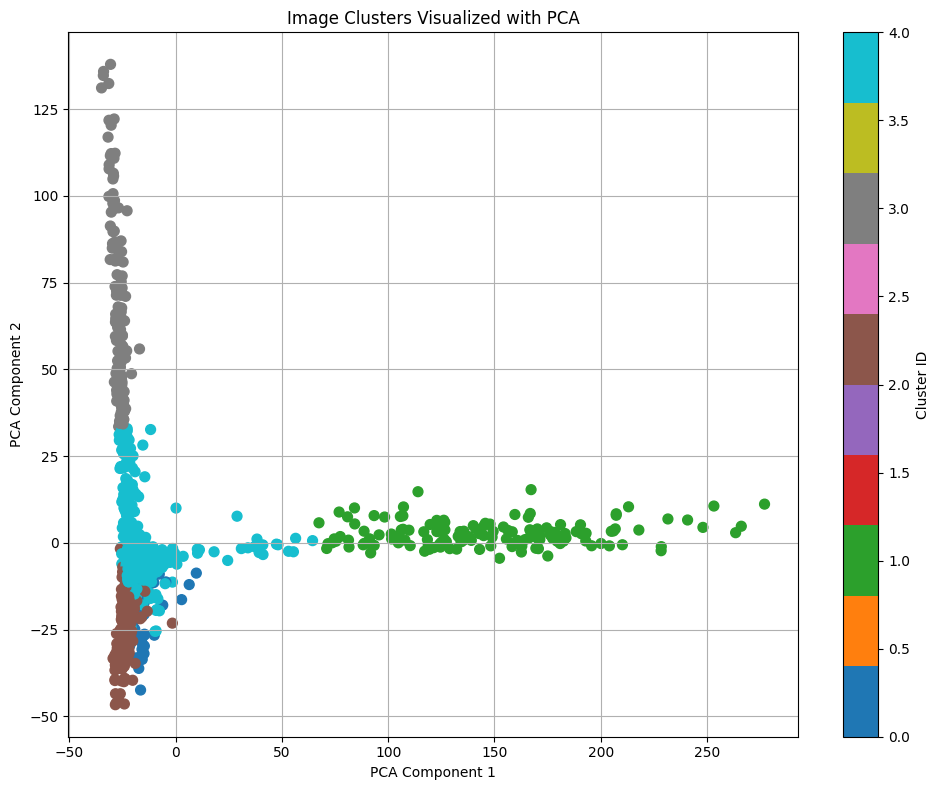

In [13]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
# from sklearn.manifold import TSNE  # Optional alternative to PCA

# Reduce features to 2D using PCA
pca = PCA(n_components=2)
reduced_features = pca.fit_transform(features)

# Plot clusters
plt.figure(figsize=(10, 8))
scatter = plt.scatter(reduced_features[:, 0], reduced_features[:, 1], c=clusters, cmap='tab10', s=50)

# Annotate with filenames if needed (optional)
# for i, fname in enumerate(filenames):
#     plt.annotate(fname, (reduced_features[i, 0], reduced_features[i, 1]), fontsize=6)

plt.title("Image Clusters Visualized with PCA")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(scatter, label='Cluster ID')
plt.grid(True)
plt.tight_layout()
plt.show()


## Continual clustering

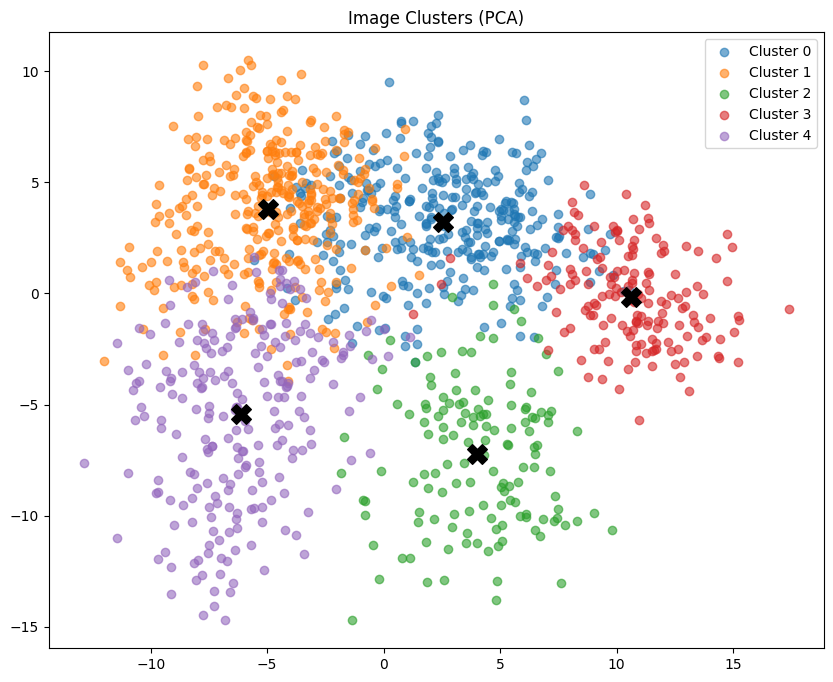

In [28]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce dimensions for visualization
pca = PCA(n_components=2)
reduced_features = pca.fit_transform(features)

# Store cluster centers in 2D
reduced_centers = pca.transform(kmeans.cluster_centers_)

# Plot
plt.figure(figsize=(10, 8))
for i in range(k):
    cluster_points = reduced_features[clusters == i]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f"Cluster {i}", alpha=0.6)
    plt.scatter(reduced_centers[i][0], reduced_centers[i][1], marker='X', s=200, c='black')  # centroids

plt.title("Image Clusters (PCA)")
plt.legend()
plt.savefig("cluster_graph.png")
plt.show()




In [ ]:
import matplotlib.pyplot as plt
import os
import numpy as np

def predict_cluster_and_plot(new_img_path, threshold=20.0):
    # Step 1: Extract and convert features
    new_feat = extract_features(new_img_path).astype(np.float64)

    # Step 2: Predict cluster
    cluster_id = kmeans.predict(np.array([new_feat], dtype=np.float64))[0]

    # Step 3: Compute distance from cluster center
    dist = np.linalg.norm(new_feat - kmeans.cluster_centers_[cluster_id])

    # Step 4: Reduce to 2D using PCA
    reduced_new = pca.transform(np.array([new_feat], dtype=np.float64))[0]

    # Step 5: Plot clusters
    plt.clf()  # 🔄 Clear the current figure
    plt.figure(figsize=(10, 8))
    for i in range(k):
        cluster_points = reduced_features[clusters == i]
        plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f"Cluster {i}", alpha=0.6)
        plt.scatter(reduced_centers[i][0], reduced_centers[i][1], marker='X', s=200, c='black')

    # Step 6: Plot new image point
    plt.scatter(reduced_new[0], reduced_new[1], c='red', s=150, label='New Image', edgecolors='black')

    plt.title(f"Prediction for: {os.path.basename(new_img_path)}")
    plt.legend()
    plt.pause(0.1)  # 🔄 Brief pause for UI to update (useful in notebooks or live scripts)
    plt.show(block=False)

    # Step 7: Anomaly detection
    if dist > threshold:
        print(f"⚠️ Possible Anomaly Detected! Distance from cluster center: {dist:.2f}")
        return cluster_id, dist, True  # anomaly=True
    else:
        print(f"✅ Assigned to Cluster {cluster_id} (Distance: {dist:.2f})")
        return cluster_id, dist, False  # anomaly=False


def evaluate_images_in_folder(folder_path, threshold=20.0):
    anomaly_count = 0
    total_images = 0

    for fname in os.listdir(folder_path):
        if fname.lower().endswith((".jpg", ".jpeg", ".png")):
            img_path = os.path.join(folder_path, fname)
            total_images += 1
            print(f"\n📸 Evaluating: {fname}")
            try:
                cluster_id, distance, is_anomaly = predict_cluster_and_plot(img_path, threshold)
                if is_anomaly:
                    anomaly_count += 1
            except Exception as e:
                print(f"❌ Error processing {fname}: {e}")

    print("\n🎯 Evaluation Summary:")
    print(f"🔍 Total Images Evaluated: {total_images}")
    print(f"⚠️ Total Anomalies Detected: {anomaly_count}")

# Call this
new_images_folder = r"D:\CSE299\batch-1"
evaluate_images_in_folder(new_images_folder)



## HDSCAN

In [1]:
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tensorflow.keras.preprocessing import image
import hdbscan
from hdbscan import prediction

# === Load MobileNetV2 for feature extraction ===
model = MobileNetV2(weights='imagenet', include_top=False, pooling='avg')

def extract_features(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    x = image.img_to_array(img)
    x = preprocess_input(x)
    x = np.expand_dims(x, axis=0)
    features = model.predict(x)
    return features[0]

# === Step 1: Feature extraction for dataset ===
image_folder = r"C:\Users\User\Downloads\Skin-disease-dataset\mixed-small"
features = []
filenames = []

for fname in os.listdir(image_folder):
    if fname.lower().endswith((".jpg", ".jpeg", ".png")):
        path = os.path.join(image_folder, fname)
        feat = extract_features(path)
        features.append(feat)
        filenames.append(fname)

features = np.array(features, dtype=np.float64)

# === Step 2: HDBSCAN clustering ===
clusterer = hdbscan.HDBSCAN(min_cluster_size=5, prediction_data=True)  # Enable prediction
clusterer.fit(features)

# === Step 3: PCA for visualization ===
pca = PCA(n_components=2)
reduced_features = pca.fit_transform(features)

# === Step 4: Store cluster labels ===
labels = clusterer.labels_
unique_clusters = set(labels)

# === Step 5: Organize images by cluster ===
output_folder = "grouped_images_hdbscan_v2"
os.makedirs(output_folder, exist_ok=True)

for cluster_id in unique_clusters:
    folder_name = "noise" if cluster_id == -1 else f"cluster_{cluster_id}"
    os.makedirs(os.path.join(output_folder, folder_name), exist_ok=True)

for fname, cluster_id in zip(filenames, labels):
    folder_name = "noise" if cluster_id == -1 else f"cluster_{cluster_id}"
    src = os.path.join(image_folder, fname)
    dst = os.path.join(output_folder, folder_name, fname)
    shutil.copy(src, dst)




1/1 [==============================] - 0s 19ms/step


C:\Users\User\AppData\Roaming\Python\Python310\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\User\AppData\Roaming\Python\Python310\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


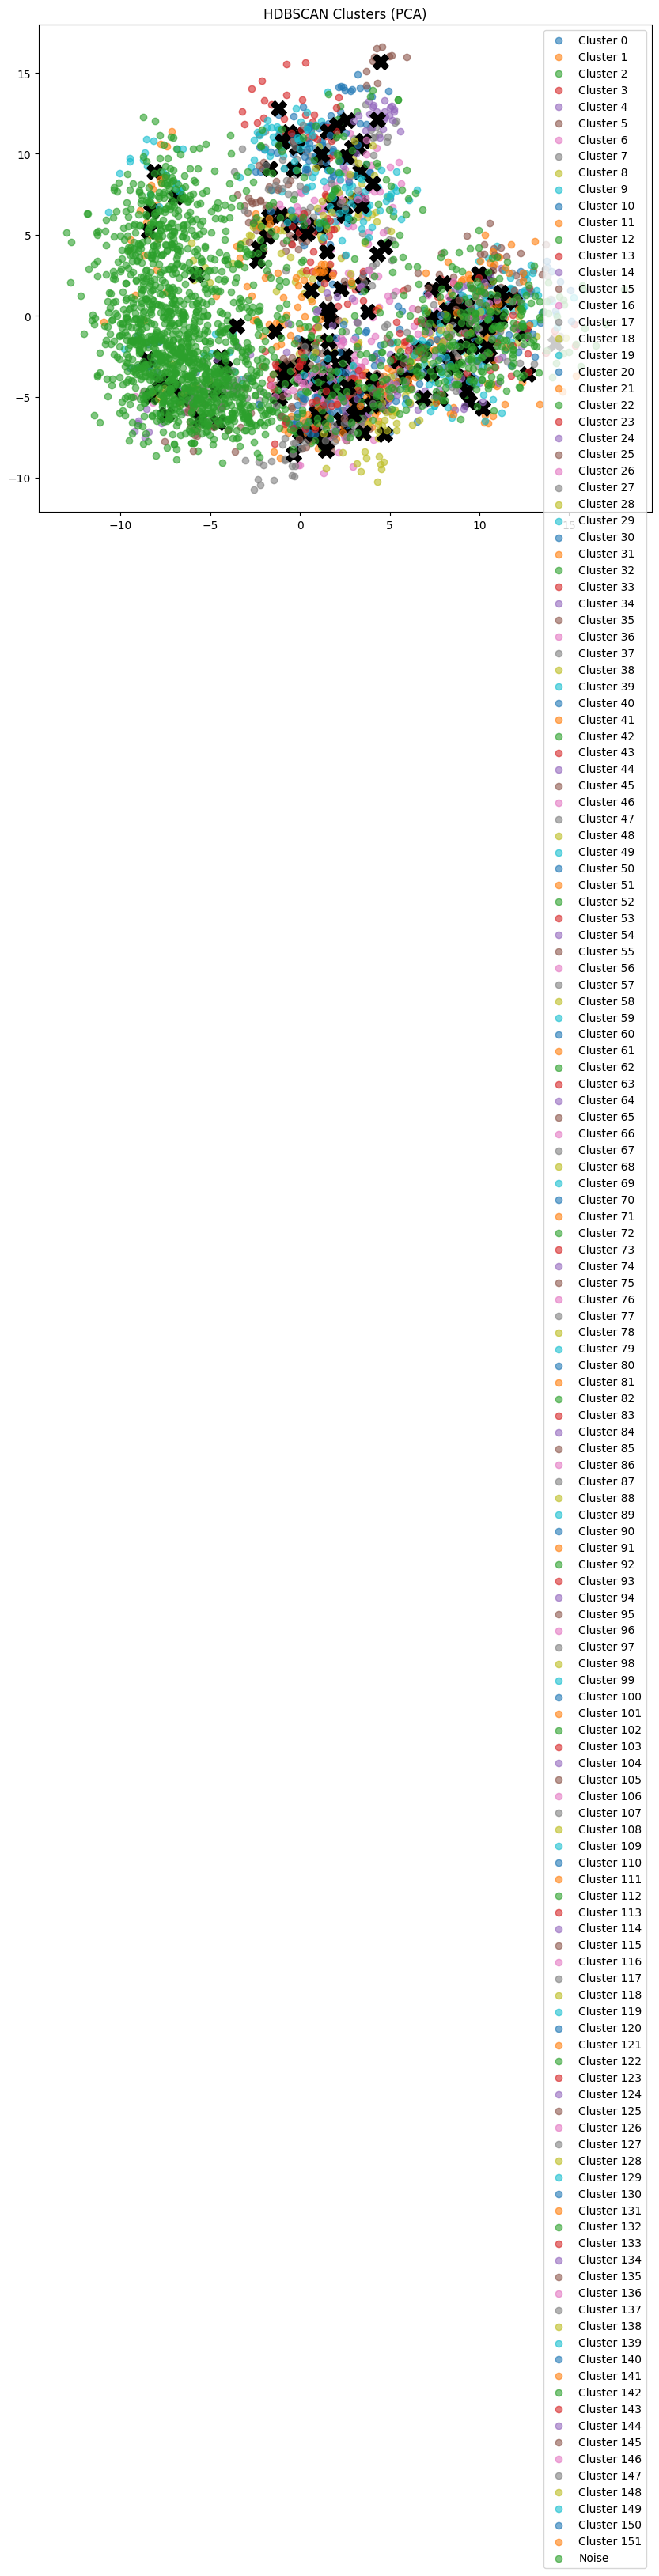

In [2]:
# === Step 6: Plot cluster map ===
reduced_centers = {}  # Optional pseudo-centers
for i in unique_clusters:
    cluster_points = reduced_features[labels == i]
    if len(cluster_points) > 0:
        reduced_centers[i] = np.mean(cluster_points, axis=0)

plt.figure(figsize=(10, 8))
for cluster_id in unique_clusters:
    cluster_points = reduced_features[labels == cluster_id]
    label_name = "Noise" if cluster_id == -1 else f"Cluster {cluster_id}"
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=label_name, alpha=0.6)
    if cluster_id in reduced_centers:
        plt.scatter(*reduced_centers[cluster_id], marker='X', s=200, c='black')

plt.legend()
plt.title("HDBSCAN Clusters (PCA)")
plt.savefig("hdbscan_cluster_graph.png")
plt.show()

In [ ]:

# === Step 7: Predict new image using approximate_predict ===
def predict_cluster_and_plot_hdbscan(new_img_path):
    new_feat = extract_features(new_img_path).astype(np.float64)
    reduced_new = pca.transform([new_feat])[0]

    # Predict cluster label and probability
    pred_label, confidence = prediction.approximate_predict(clusterer, [new_feat])
    pred_label = pred_label[0]
    confidence = confidence[0]

    # Plot with existing
    plt.clf()
    plt.figure(figsize=(10, 8))
    for cluster_id in unique_clusters:
        cluster_points = reduced_features[labels == cluster_id]
        label_name = "Noise" if cluster_id == -1 else f"Cluster {cluster_id}"
        plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=label_name, alpha=0.6)

    plt.scatter(reduced_new[0], reduced_new[1], c='red', s=150, label='New Image', edgecolors='black')
    plt.title(f"Prediction: {os.path.basename(new_img_path)} - Cluster {pred_label} (Confidence: {confidence:.2f})")
    plt.legend()
    plt.pause(0.1)
    plt.show(block=False)

    if pred_label == -1 or confidence < 0.3:
        print(f"⚠️ Likely Anomaly Detected! Label: {pred_label}, Confidence: {confidence:.2f}")
        return pred_label, confidence, True
    else:
        print(f"✅ Assigned to Cluster {pred_label} (Confidence: {confidence:.2f})")
        return pred_label, confidence, False

# === Step 8: Evaluate new images in folder ===
def evaluate_images_in_folder_hdbscan(folder_path):
    anomaly_count = 0
    total_images = 0

    for fname in os.listdir(folder_path):
        if fname.lower().endswith((".jpg", ".jpeg", ".png")):
            img_path = os.path.join(folder_path, fname)
            total_images += 1
            print(f"\n📸 Evaluating: {fname}")
            try:
                _, _, is_anomaly = predict_cluster_and_plot_hdbscan(img_path)
                if is_anomaly:
                    anomaly_count += 1
            except Exception as e:
                print(f"❌ Error processing {fname}: {e}")

    print("\n🎯 Evaluation Summary:")
    print(f"🔍 Total Images Evaluated: {total_images}")
    print(f"⚠️ Total Anomalies Detected: {anomaly_count}")

# === Final Call ===
new_images_folder = r"D:\CSE299\batch-1"
evaluate_images_in_folder_hdbscan(new_images_folder)